In [1]:
#============================================================
# Celda 1 — Setup y carga
#============================================================
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import matplotlib.cm as cm
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

# Funciona en local (Codespaces/Jupyter), CI (papermill) y cualquier entorno
ROOT = Path.cwd()
while not (ROOT / "requirements.txt").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if not (ROOT / "requirements.txt").exists():
    raise FileNotFoundError(
        f"No se encontró requirements.txt subiendo desde {Path.cwd()}\n"
        "Asegúrate de ejecutar desde dentro del repo."
    )
os.chdir(ROOT)
print(f"✅ ROOT: {ROOT}")

OUTPUT = Path("output")
FIGS   = OUTPUT / "08_visualizaciones_finales" / "figs"
FIGS.mkdir(parents=True, exist_ok=True)

master = pd.read_parquet(OUTPUT / "merged/master_provincia_anio.parquet")

STYLE = {
    "figure.dpi":        150,
    "figure.facecolor":  "white",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "font.family":       "DejaVu Sans",
    "axes.titlesize":    13,
    "axes.labelsize":    11,
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
}
plt.rcParams.update(STYLE)

# Paleta corporativa del TFG
C_POS  = "#2980b9"   # azul — atracción
C_NEG  = "#e74c3c"   # rojo — expulsión
C_COB  = "#27ae60"   # verde — cobertura
C_COMP = "#e67e22"   # naranja — compraventas
C_NEUT = "#7f8c8d"   # gris neutro

print(f"✅ Master cargado: {master.shape} | provincias: {master['provincia'].nunique()} | años: {sorted(master['anyo'].unique())}")

✅ ROOT: /home/runner/work/TFG_Spain-s_Migratory_Flow/TFG_Spain-s_Migratory_Flow
✅ Master cargado: (2184, 15) | provincias: 52 | años: [np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021)]


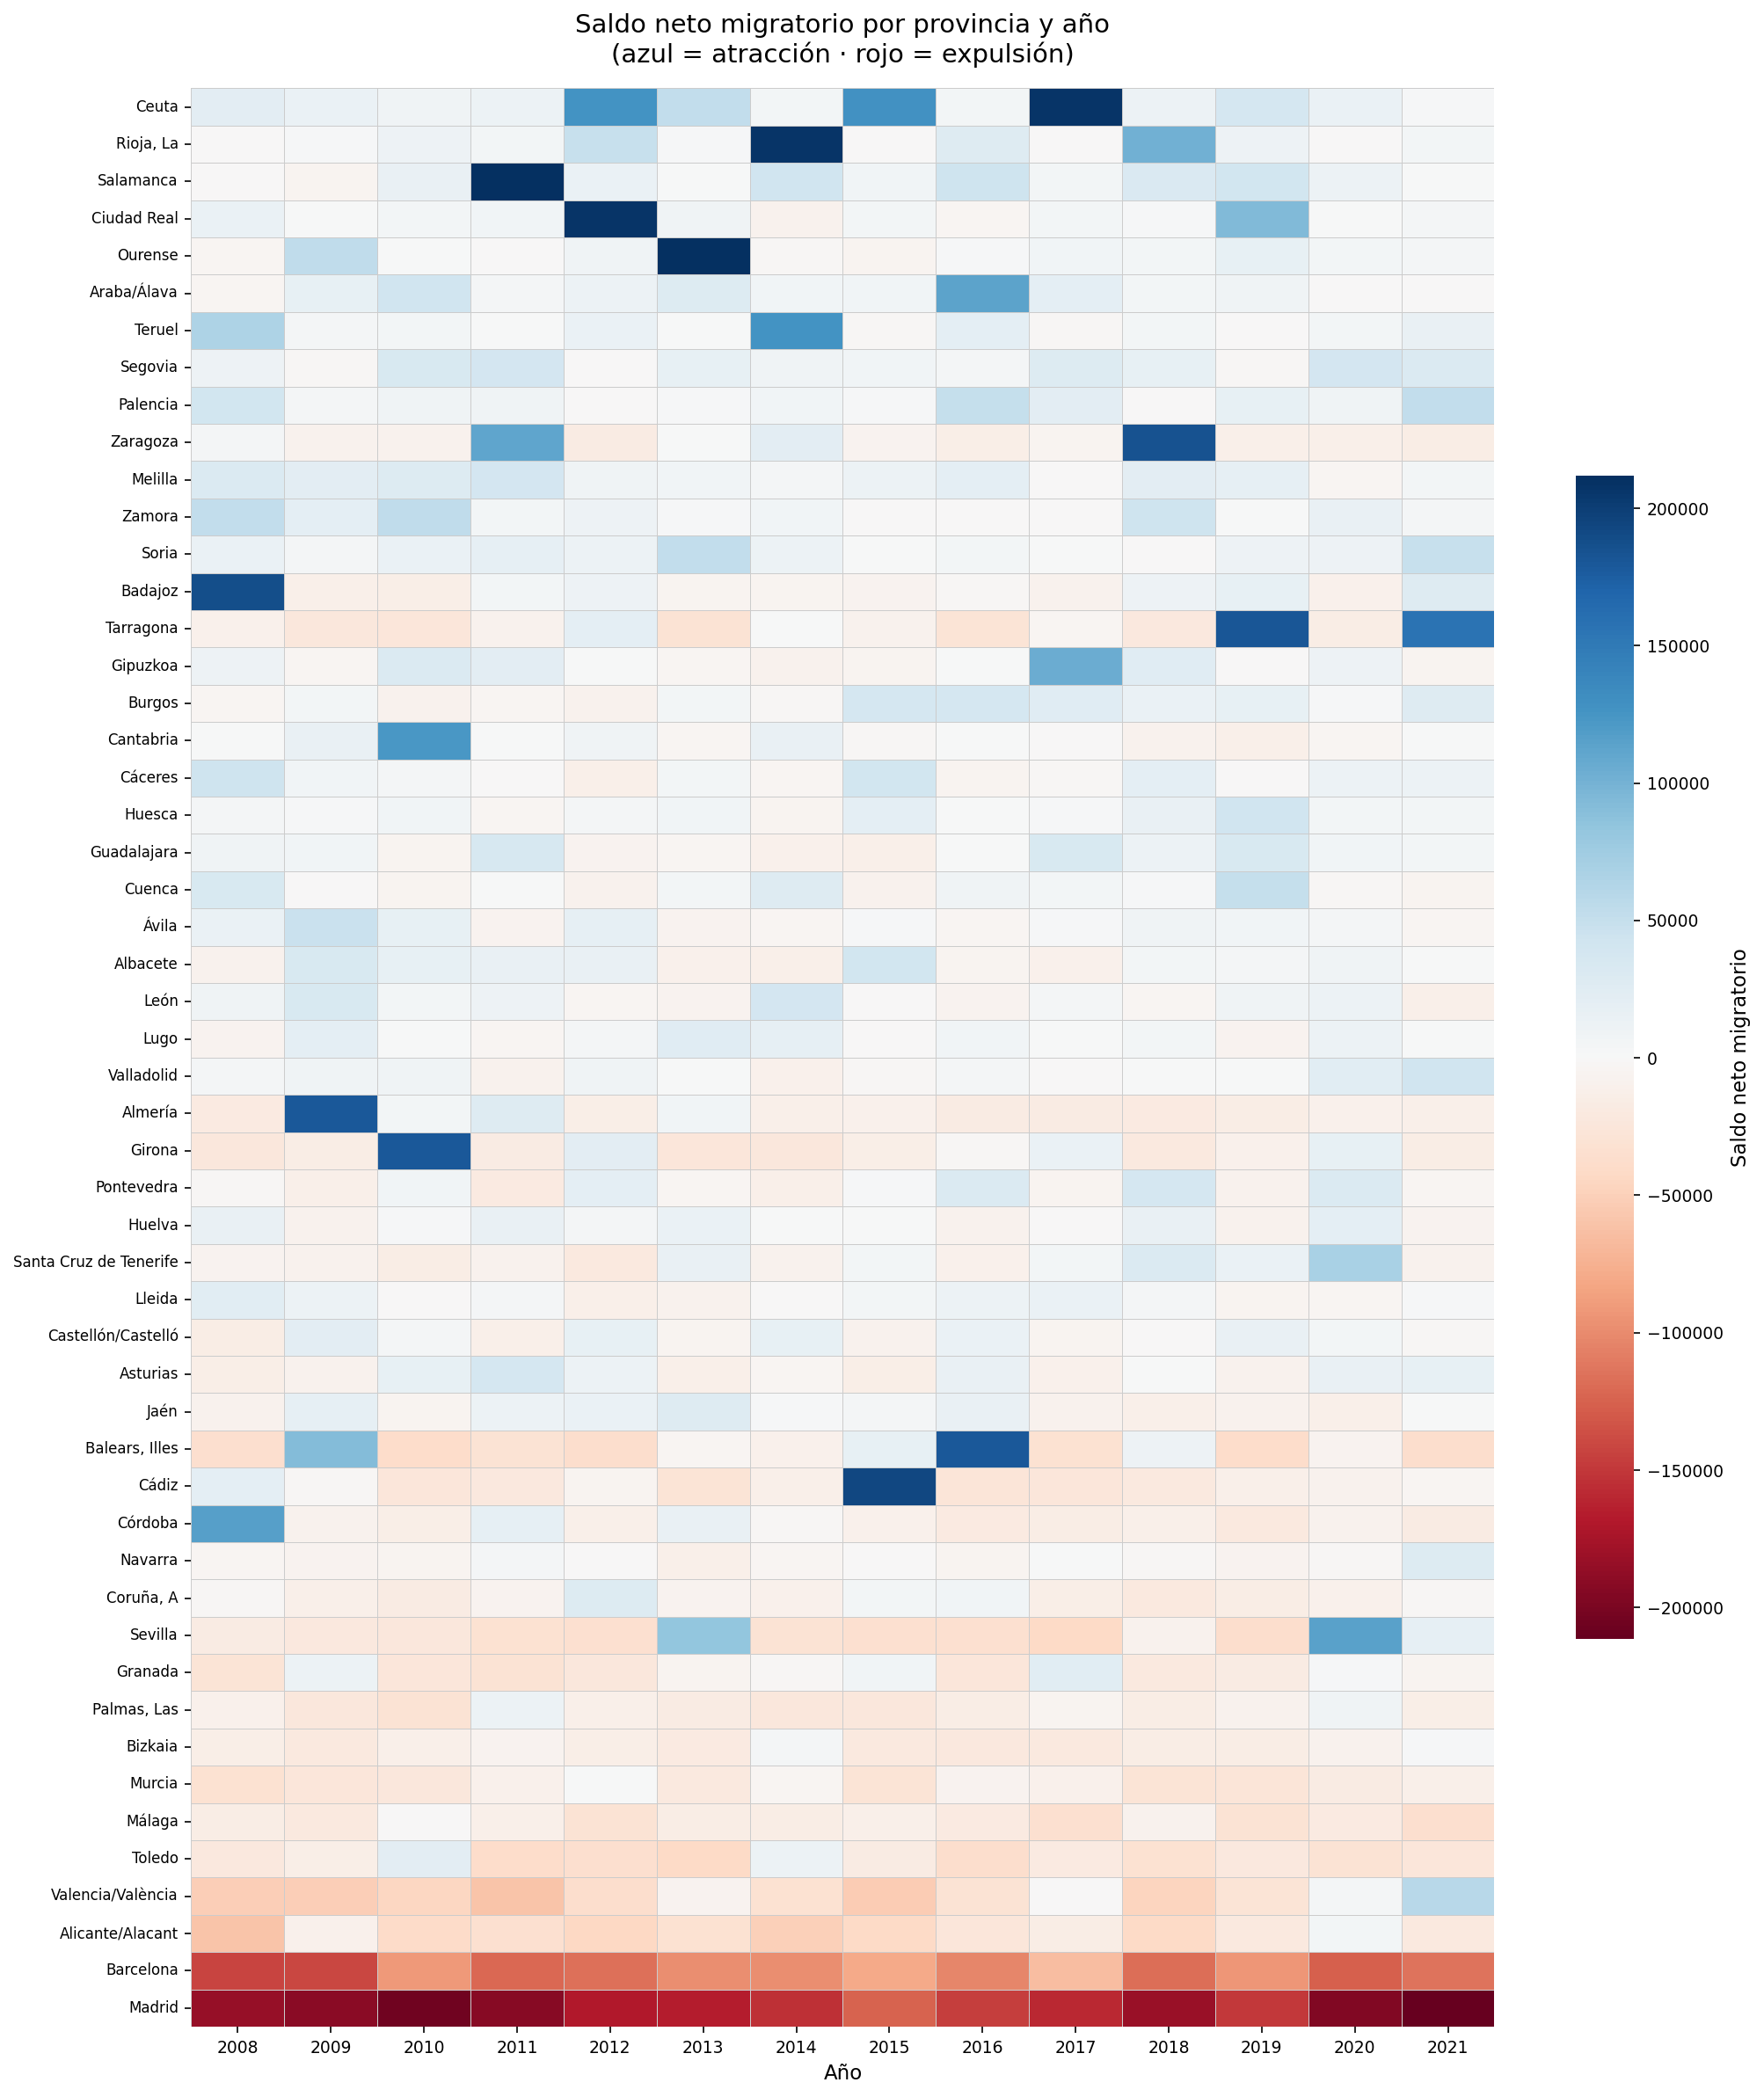

✅ 01_heatmap_provincia_anio.png


In [2]:
#============================================================
# Celda 2 — Heatmap provincia × año (saldo neto)
#============================================================
pivot = master.pivot_table(
    index="provincia", columns="anyo", values="saldo_neto", aggfunc="sum"
)
# Ordenar por saldo medio
pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(14, 16))

sns.heatmap(
    pivot,
    ax=ax,
    cmap="RdBu",
    center=0,
    linewidths=0.3,
    linecolor="#cccccc",
    fmt=".0f",
    annot=False,
    cbar_kws={"label": "Saldo neto migratorio", "shrink": 0.6}
)
ax.set_title("Saldo neto migratorio por provincia y año\n(azul = atracción · rojo = expulsión)",
             pad=14, fontsize=14)
ax.set_xlabel("Año")
ax.set_ylabel("")
ax.tick_params(axis="x", rotation=0)
ax.tick_params(axis="y", labelsize=8)

plt.tight_layout()
plt.savefig(FIGS / "01_heatmap_provincia_anio.png")
plt.show()
print("✅ 01_heatmap_provincia_anio.png")

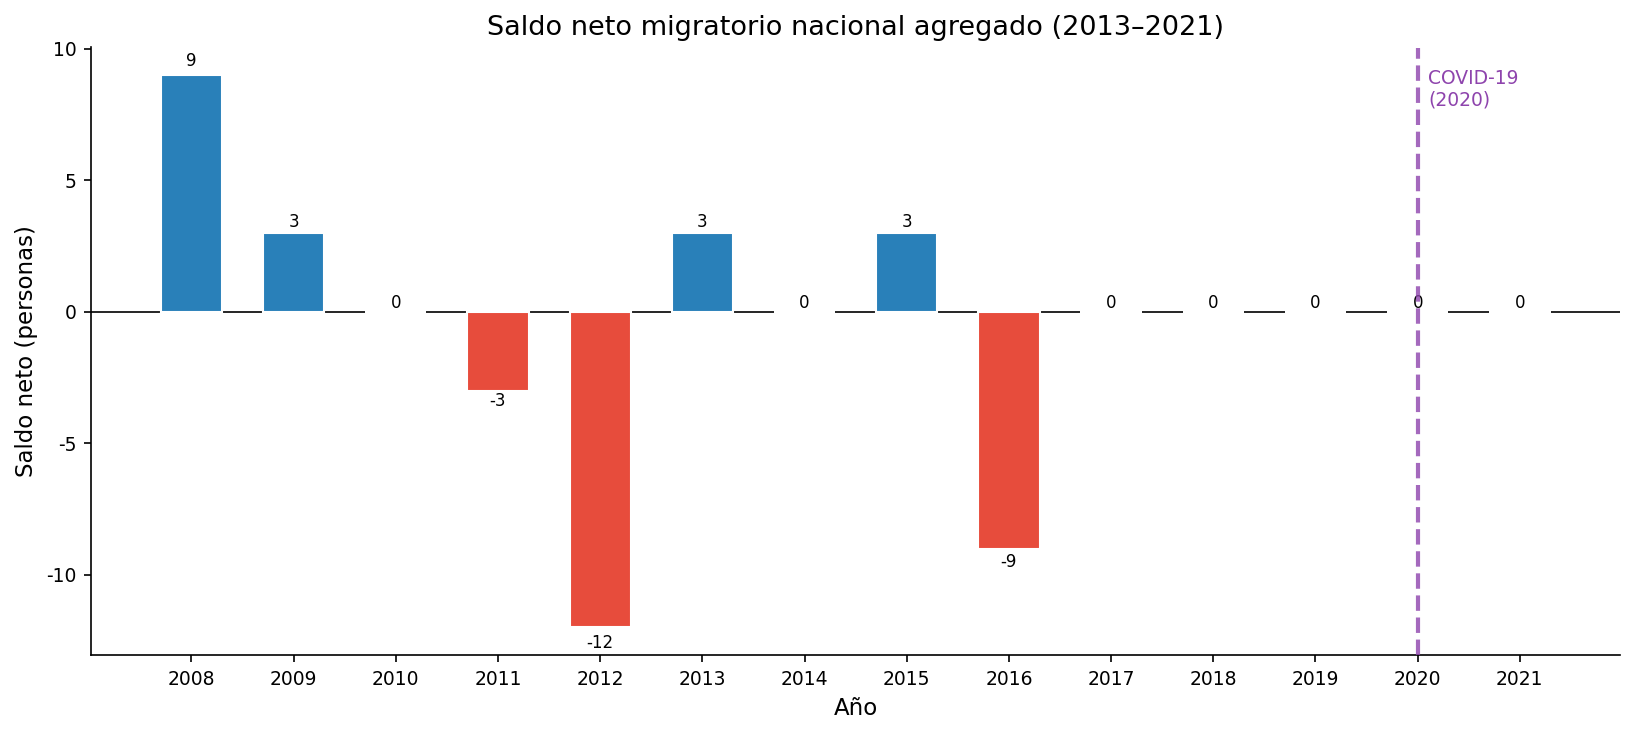

✅ 02_evolucion_saldo_nacional.png


In [3]:
#============================================================
# Celda 3 — Evolución saldo nacional agregado + COVID
#============================================================
saldo_nac = master.groupby("anyo")["saldo_neto"].sum().reset_index()

fig, ax = plt.subplots(figsize=(11, 5))

bars = ax.bar(saldo_nac["anyo"], saldo_nac["saldo_neto"],
              color=[C_POS if v >= 0 else C_NEG for v in saldo_nac["saldo_neto"]],
              edgecolor="white", width=0.6, zorder=3)

ax.axhline(0, color="black", linewidth=0.8)
ax.axvline(2020, color="#8e44ad", linewidth=2, linestyle="--", alpha=0.8, zorder=4)
ax.text(2020.1, ax.get_ylim()[1] * 0.92, "COVID-19\n(2020)", color="#8e44ad",
        fontsize=9, va="top")

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_xticks(saldo_nac["anyo"])
ax.set_title("Saldo neto migratorio nacional agregado (2013–2021)")
ax.set_xlabel("Año")
ax.set_ylabel("Saldo neto (personas)")

for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2,
            h + (abs(h) * 0.02) * (1 if h >= 0 else -1),
            f"{int(h):,}", ha="center",
            va="bottom" if h >= 0 else "top", fontsize=8)

plt.tight_layout()
plt.savefig(FIGS / "02_evolucion_saldo_nacional.png")
plt.show()
print("✅ 02_evolucion_saldo_nacional.png")

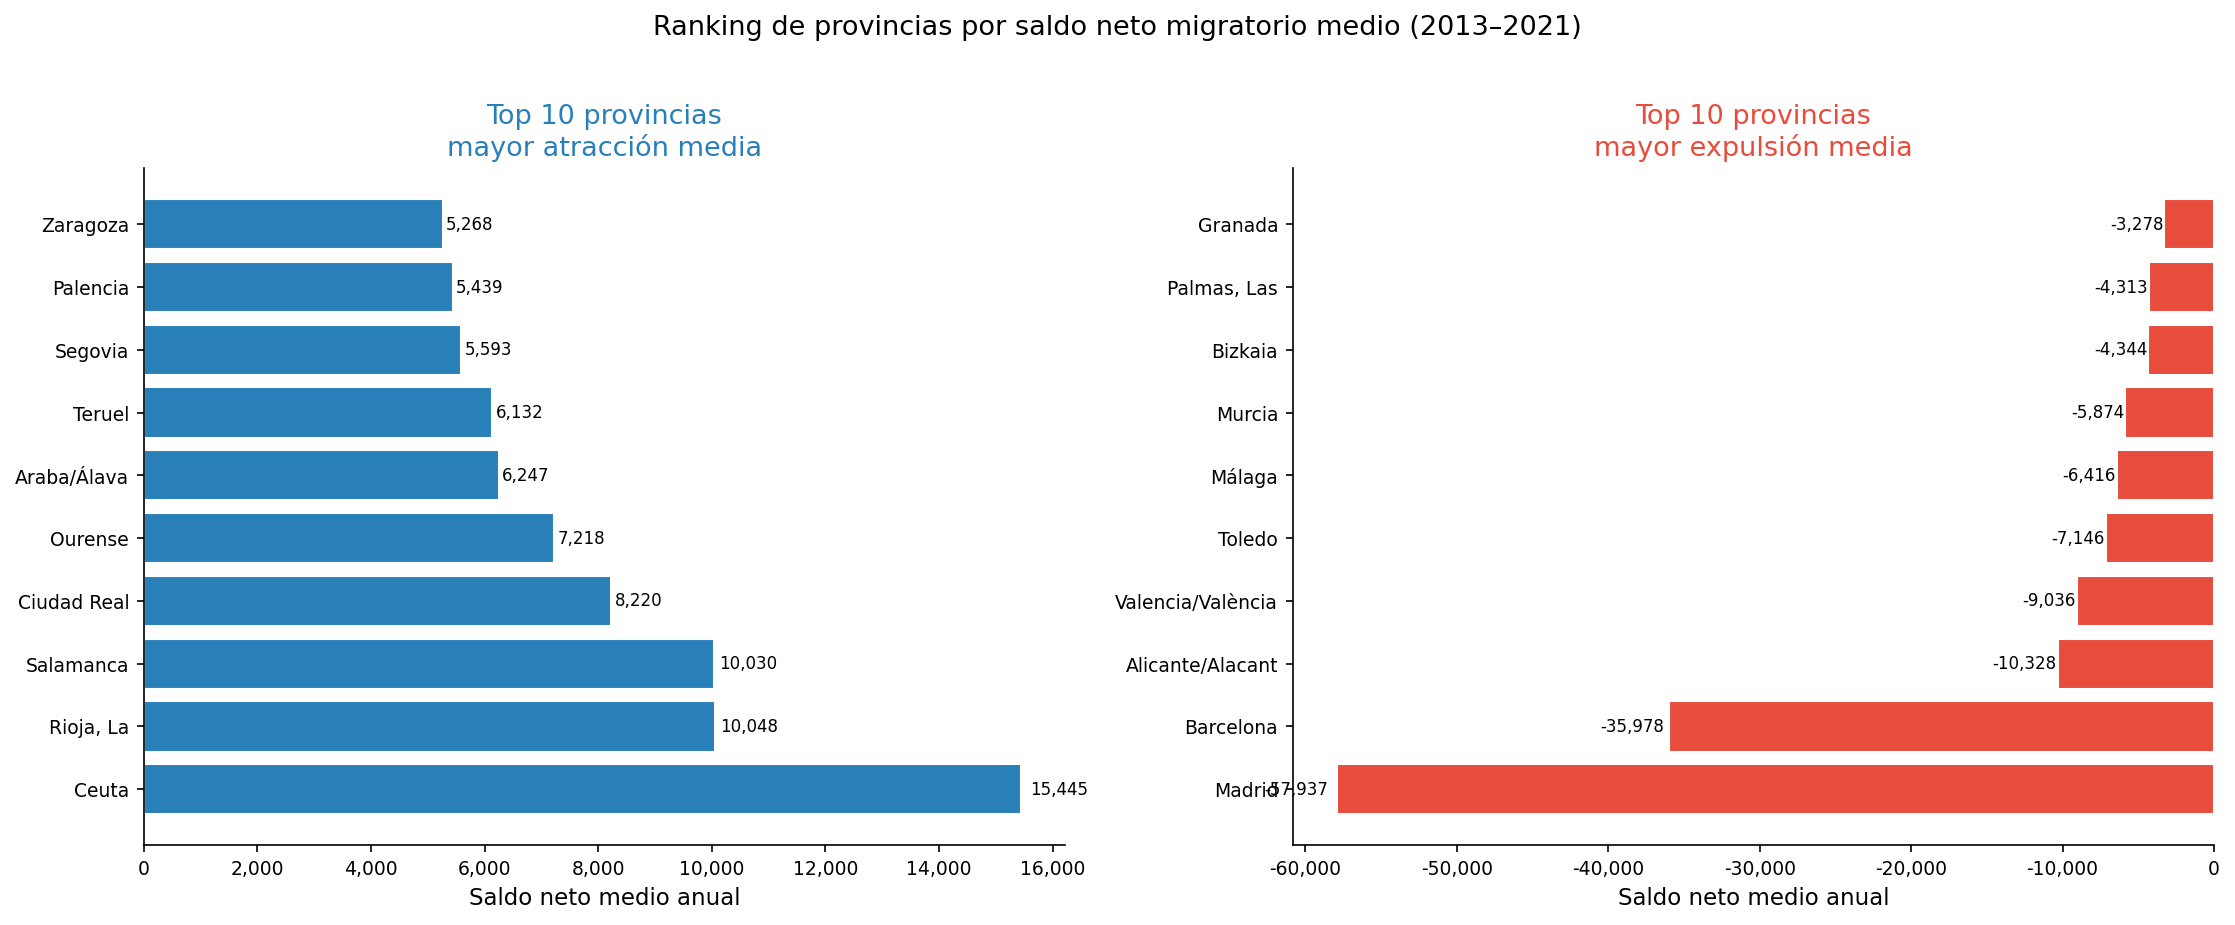

✅ 03_ranking_ganadoras_perdedoras.png


In [4]:
#============================================================
# Celda 4 — Top 10 ganadoras vs perdedoras
#============================================================
ranking = (master.groupby("provincia")["saldo_neto"]
           .mean().reset_index()
           .sort_values("saldo_neto", ascending=False))

top10    = ranking.head(10)
bottom10 = ranking.tail(10).sort_values("saldo_neto")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Ganadoras
axes[0].barh(top10["provincia"], top10["saldo_neto"],
             color=C_POS, edgecolor="white")
axes[0].set_title("Top 10 provincias\nmayor atracción media", color=C_POS)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
axes[0].set_xlabel("Saldo neto medio anual")
for i, (v, p) in enumerate(zip(top10["saldo_neto"], top10["provincia"])):
    axes[0].text(v + abs(v)*0.01, i, f"{v:,.0f}", va="center", fontsize=8)

# Perdedoras
axes[1].barh(bottom10["provincia"], bottom10["saldo_neto"],
             color=C_NEG, edgecolor="white")
axes[1].set_title("Top 10 provincias\nmayor expulsión media", color=C_NEG)
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
axes[1].set_xlabel("Saldo neto medio anual")
for i, v in enumerate(bottom10["saldo_neto"]):
    axes[1].text(v - abs(v)*0.01, i, f"{v:,.0f}", va="center", ha="right", fontsize=8)

plt.suptitle("Ranking de provincias por saldo neto migratorio medio (2013–2021)",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIGS / "03_ranking_ganadoras_perdedoras.png", bbox_inches="tight")
plt.show()
print("✅ 03_ranking_ganadoras_perdedoras.png")

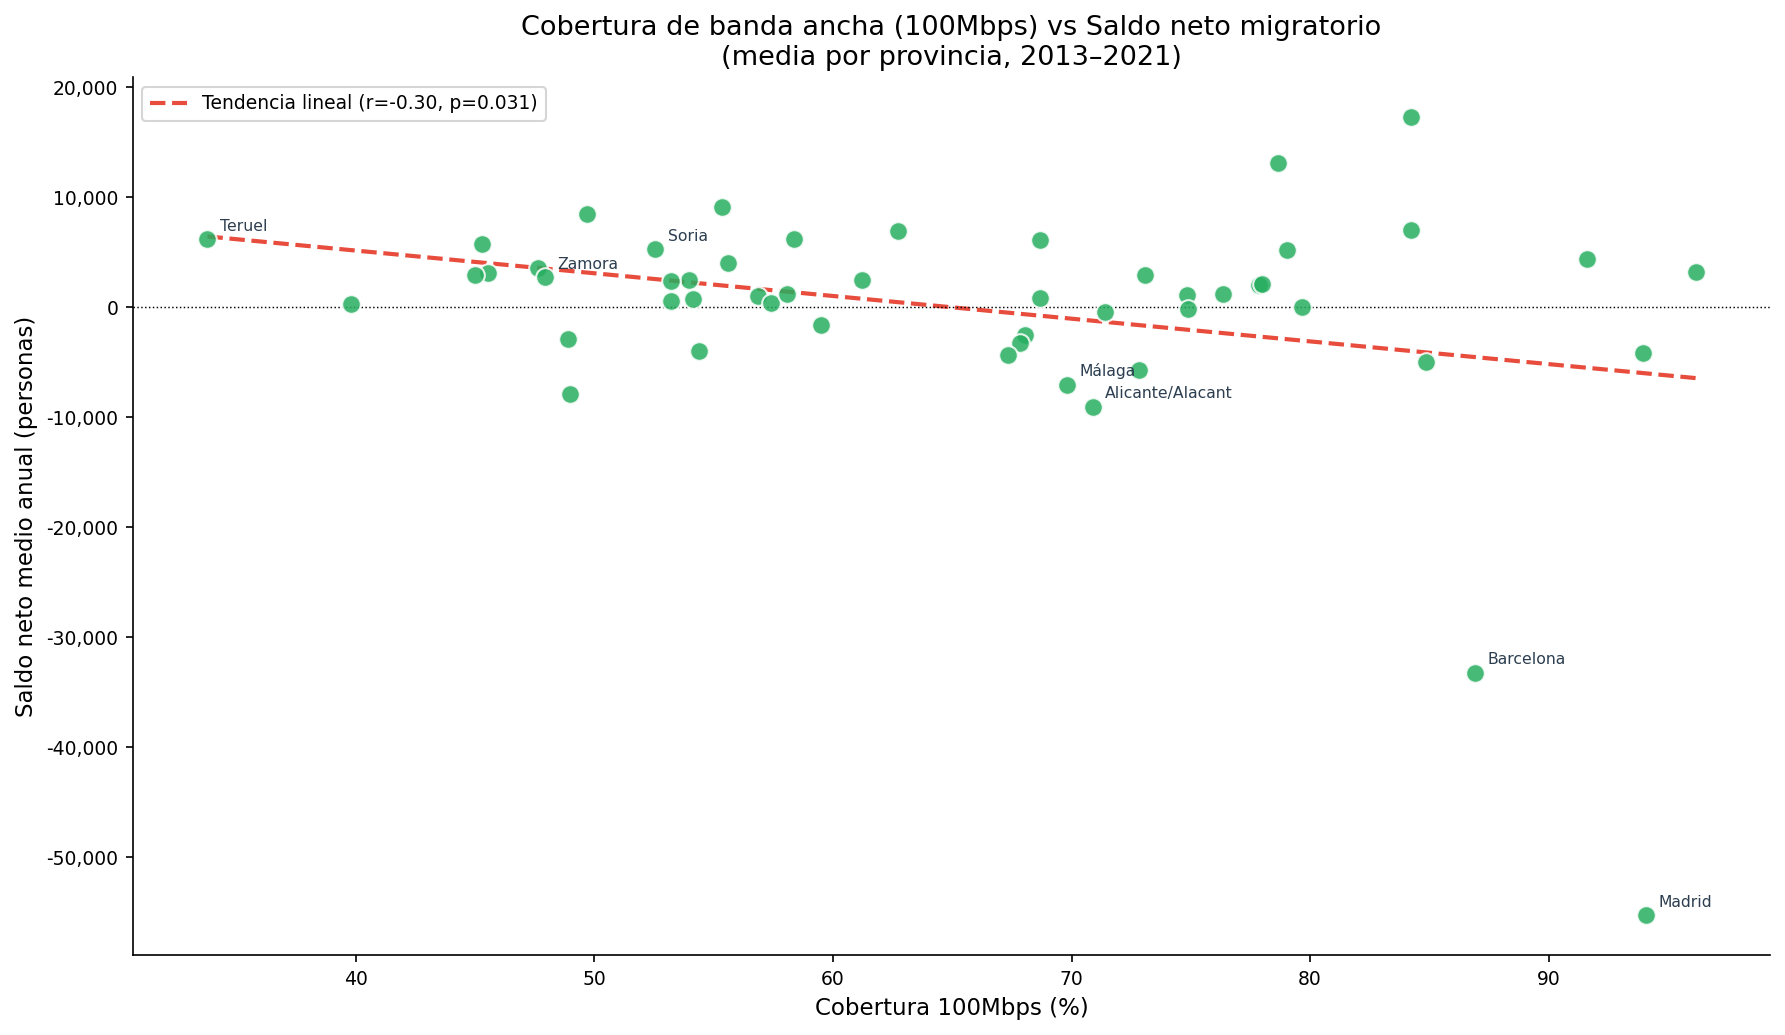

✅ 04_scatter_cobertura_saldo_anotado.png


In [5]:
#============================================================
# Celda 5 — Scatter cobertura vs saldo neto (figura clave TFG)
#============================================================
from scipy import stats

sub = master[["provincia", "anyo", "saldo_neto", "cob_100mbps_pct",
              "compraventas_per_capita"]].dropna().copy()

media_prov = sub.groupby("provincia")[["saldo_neto", "cob_100mbps_pct"]].mean().reset_index()

# Regresión para línea de tendencia
slope, intercept, r, p, _ = stats.linregress(
    media_prov["cob_100mbps_pct"], media_prov["saldo_neto"]
)
x_line = np.linspace(media_prov["cob_100mbps_pct"].min(),
                     media_prov["cob_100mbps_pct"].max(), 100)
y_line = slope * x_line + intercept

fig, ax = plt.subplots(figsize=(12, 7))

sc = ax.scatter(media_prov["cob_100mbps_pct"], media_prov["saldo_neto"],
                color=C_COB, edgecolors="white", s=80, alpha=0.85, zorder=3)

ax.plot(x_line, y_line, color=C_NEG, linewidth=2, linestyle="--",
        label=f"Tendencia lineal (r={r:.2f}, p={p:.3f})")

# Anotar outliers destacados
DESTACAR = ["Madrid", "Barcelona", "Málaga", "Soria", "Teruel", "Zamora",
            "Islas Baleares", "Alicante/Alacant"]
for _, row in media_prov.iterrows():
    if row["provincia"] in DESTACAR:
        ax.annotate(row["provincia"],
                    xy=(row["cob_100mbps_pct"], row["saldo_neto"]),
                    xytext=(6, 4), textcoords="offset points",
                    fontsize=7.5, color="#2c3e50")

ax.axhline(0, color="black", linewidth=0.7, linestyle=":")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_title("Cobertura de banda ancha (100Mbps) vs Saldo neto migratorio\n"
             "(media por provincia, 2013–2021)")
ax.set_xlabel("Cobertura 100Mbps (%)")
ax.set_ylabel("Saldo neto medio anual (personas)")
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIGS / "04_scatter_cobertura_saldo_anotado.png")
plt.show()
print("✅ 04_scatter_cobertura_saldo_anotado.png")

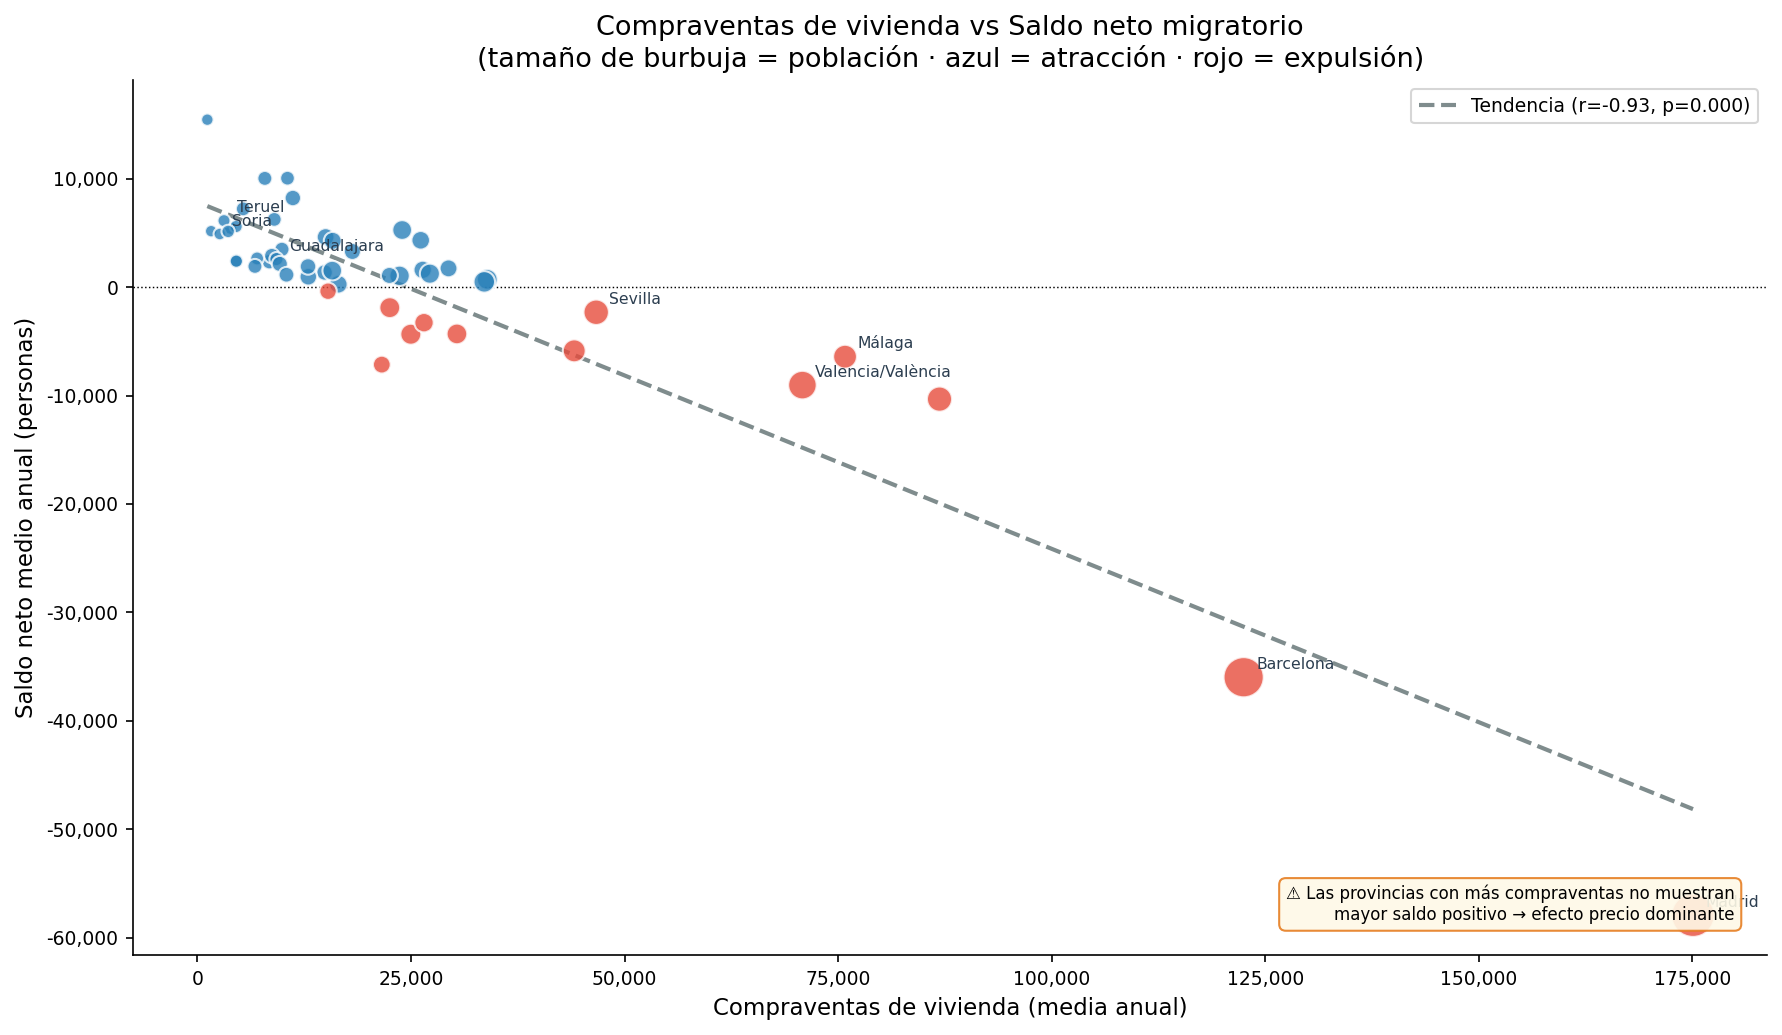

✅ 05_paradoja_compraventas_saldo.png


In [6]:
#============================================================
# Celda 6 — Paradoja compraventas: más compraventas ≠ mayor atracción
#============================================================
media_comp = master.groupby("provincia")[
    ["saldo_neto", "compraventas_vivienda", "poblacion_provincia"]
].mean().reset_index()

# Color según saldo positivo/negativo
colores = [C_POS if v >= 0 else C_NEG for v in media_comp["saldo_neto"]]
sizes   = (media_comp["poblacion_provincia"] / media_comp["poblacion_provincia"].max()) * 400 + 30

slope2, intercept2, r2, p2, _ = stats.linregress(
    media_comp["compraventas_vivienda"], media_comp["saldo_neto"]
)
x2 = np.linspace(media_comp["compraventas_vivienda"].min(),
                 media_comp["compraventas_vivienda"].max(), 100)

fig, ax = plt.subplots(figsize=(12, 7))

ax.scatter(media_comp["compraventas_vivienda"], media_comp["saldo_neto"],
           c=colores, s=sizes, edgecolors="white", alpha=0.8, zorder=3)

ax.plot(x2, slope2 * x2 + intercept2,
        color=C_NEUT, linewidth=2, linestyle="--",
        label=f"Tendencia (r={r2:.2f}, p={p2:.3f})")

DESTACAR2 = ["Madrid", "Barcelona", "Valencia/València", "Sevilla",
             "Soria", "Teruel", "Guadalajara", "Málaga"]
for _, row in media_comp.iterrows():
    if row["provincia"] in DESTACAR2:
        ax.annotate(row["provincia"],
                    xy=(row["compraventas_vivienda"], row["saldo_neto"]),
                    xytext=(6, 4), textcoords="offset points",
                    fontsize=7.5, color="#2c3e50")

ax.axhline(0, color="black", linewidth=0.7, linestyle=":")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_title("Compraventas de vivienda vs Saldo neto migratorio\n"
             "(tamaño de burbuja = población · azul = atracción · rojo = expulsión)")
ax.set_xlabel("Compraventas de vivienda (media anual)")
ax.set_ylabel("Saldo neto medio anual (personas)")
ax.legend(fontsize=9)

# Nota paradoja
ax.text(0.98, 0.04,
        "⚠ Las provincias con más compraventas no muestran\n"
        "mayor saldo positivo → efecto precio dominante",
        transform=ax.transAxes, fontsize=8, ha="right",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="#fef9e7", edgecolor=C_COMP, alpha=0.9))

plt.tight_layout()
plt.savefig(FIGS / "05_paradoja_compraventas_saldo.png")
plt.show()
print("✅ 05_paradoja_compraventas_saldo.png")

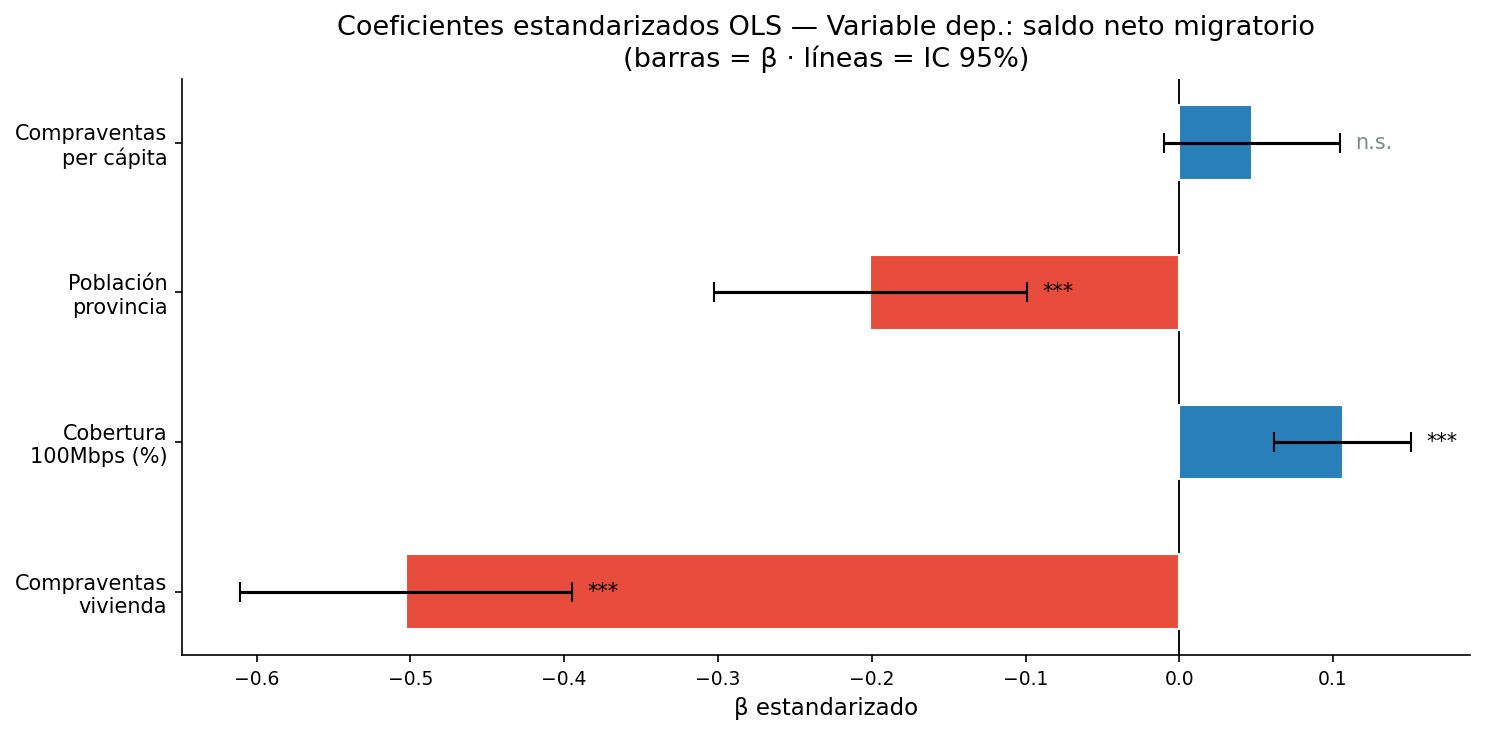

✅ 06_coeficientes_ols_ic95.png


In [7]:
#============================================================
# Celda 7 — Coeficientes OLS estandarizados con intervalos de confianza
#============================================================
import statsmodels.formula.api as smf
from sklearn.preprocessing import StandardScaler

vars_model = ["compraventas_vivienda", "cob_100mbps_pct",
              "poblacion_provincia", "compraventas_per_capita"]

sub2 = master[["saldo_neto", "provincia", "anyo"] + vars_model].dropna().copy()
scaler = StandardScaler()
sub2_std = sub2.copy()
sub2_std[vars_model + ["saldo_neto"]] = scaler.fit_transform(sub2[vars_model + ["saldo_neto"]])

modelo_std = smf.ols(
    "saldo_neto ~ compraventas_vivienda + cob_100mbps_pct + "
    "poblacion_provincia + compraventas_per_capita",
    data=sub2_std
).fit()

LABELS = {
    "compraventas_vivienda":  "Compraventas\nvivienda",
    "cob_100mbps_pct":        "Cobertura\n100Mbps (%)",
    "poblacion_provincia":    "Población\nprovincia",
    "compraventas_per_capita":"Compraventas\nper cápita",
}

coefs  = modelo_std.params[vars_model]
ci_low = modelo_std.conf_int().loc[vars_model, 0]
ci_hi  = modelo_std.conf_int().loc[vars_model, 1]
pvals  = modelo_std.pvalues[vars_model]
labels = [LABELS[v] for v in vars_model]
colors = [C_POS if c > 0 else C_NEG for c in coefs]

fig, ax = plt.subplots(figsize=(10, 5))

y_pos = np.arange(len(vars_model))
ax.barh(y_pos, coefs, color=colors, edgecolor="white", height=0.5, zorder=3)
ax.errorbar(coefs, y_pos,
            xerr=[coefs - ci_low, ci_hi - coefs],
            fmt="none", color="black", capsize=5, linewidth=1.5, zorder=4)

ax.axvline(0, color="black", linewidth=0.9)
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=10)
ax.set_title("Coeficientes estandarizados OLS — Variable dep.: saldo neto migratorio\n"
             "(barras = β · líneas = IC 95%)")
ax.set_xlabel("β estandarizado")

for i, (c, p) in enumerate(zip(coefs, pvals)):
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "n.s."
    ax.text(ci_hi.iloc[i] + 0.01, i, sig, va="center", fontsize=10,
            color="black" if sig != "n.s." else C_NEUT)

plt.tight_layout()
plt.savefig(FIGS / "06_coeficientes_ols_ic95.png")
plt.show()
print("✅ 06_coeficientes_ols_ic95.png")

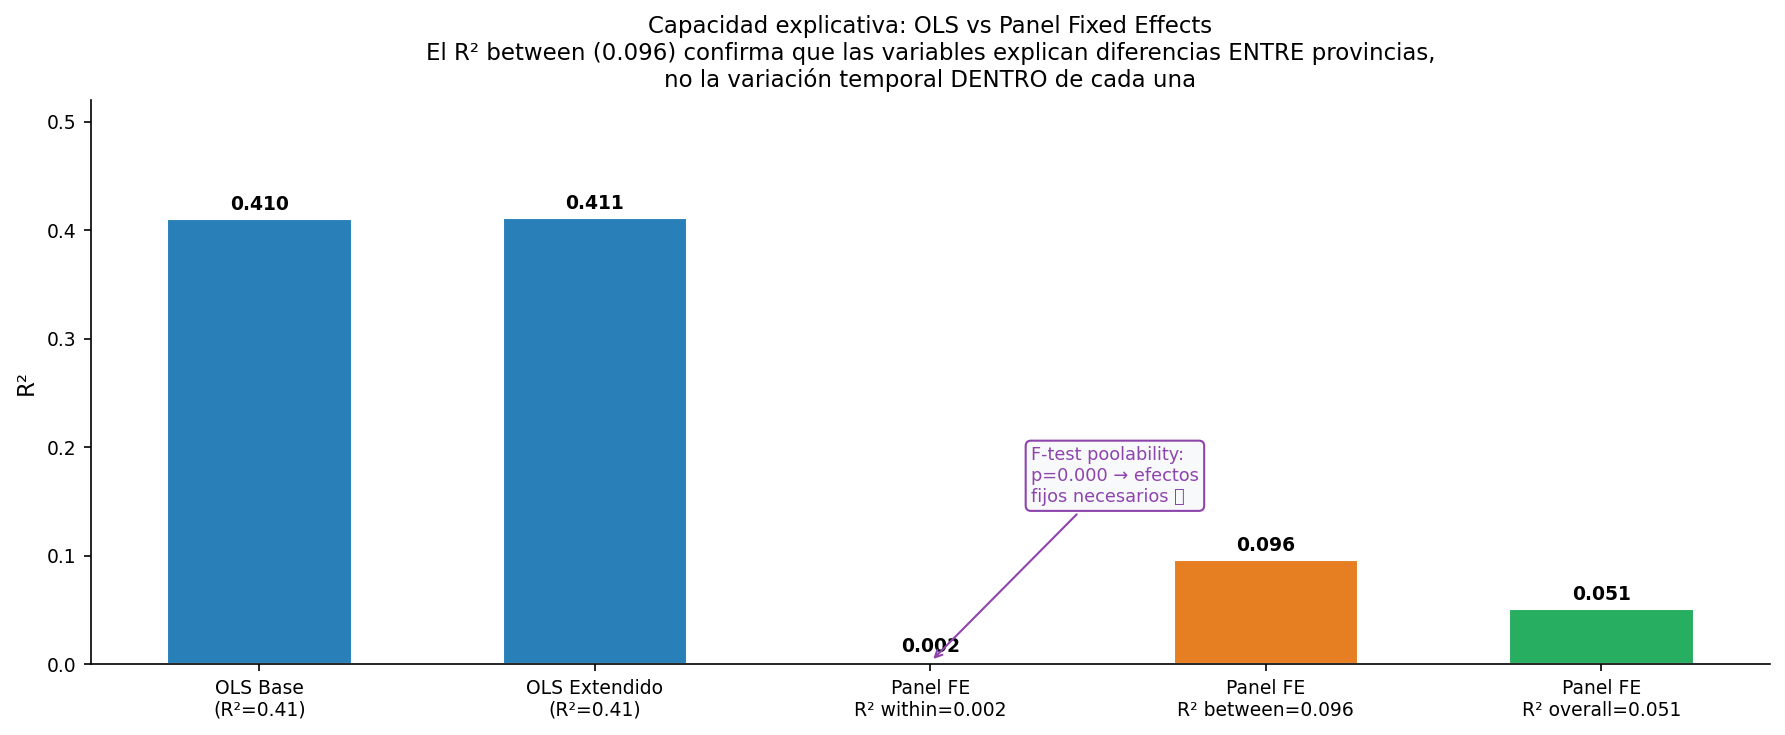

✅ 07_r2_comparativa_modelos.png


In [8]:
#============================================================
# Celda 8 — R² OLS vs Panel FE (argumento metodológico TFG)
#============================================================
modelos = ["OLS Base\n(R²=0.41)", "OLS Extendido\n(R²=0.41)", "Panel FE\nR² within=0.002",
           "Panel FE\nR² between=0.096", "Panel FE\nR² overall=0.051"]
valores = [0.410, 0.411, 0.0023, 0.096, 0.051]
colores_bar = [C_POS, C_POS, C_NEG, C_COMP, C_COB]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(modelos, valores, color=colores_bar, edgecolor="white", width=0.55)

for bar, v in zip(bars, valores):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.005,
            f"{v:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.set_ylim(0, 0.52)
ax.set_ylabel("R²")
ax.set_title("Capacidad explicativa: OLS vs Panel Fixed Effects\n"
             "El R² between (0.096) confirma que las variables explican diferencias ENTRE provincias,\n"
             "no la variación temporal DENTRO de cada una",
             fontsize=11)

# Anotación F-test poolability
ax.annotate("F-test poolability:\np=0.000 → efectos\nfijos necesarios ✅",
            xy=(2, 0.0023), xytext=(2.3, 0.15),
            arrowprops=dict(arrowstyle="->", color="#8e44ad"),
            fontsize=8.5, color="#8e44ad",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="#f8f9fa", edgecolor="#8e44ad"))

plt.tight_layout()
plt.savefig(FIGS / "07_r2_comparativa_modelos.png")
plt.show()
print("✅ 07_r2_comparativa_modelos.png")

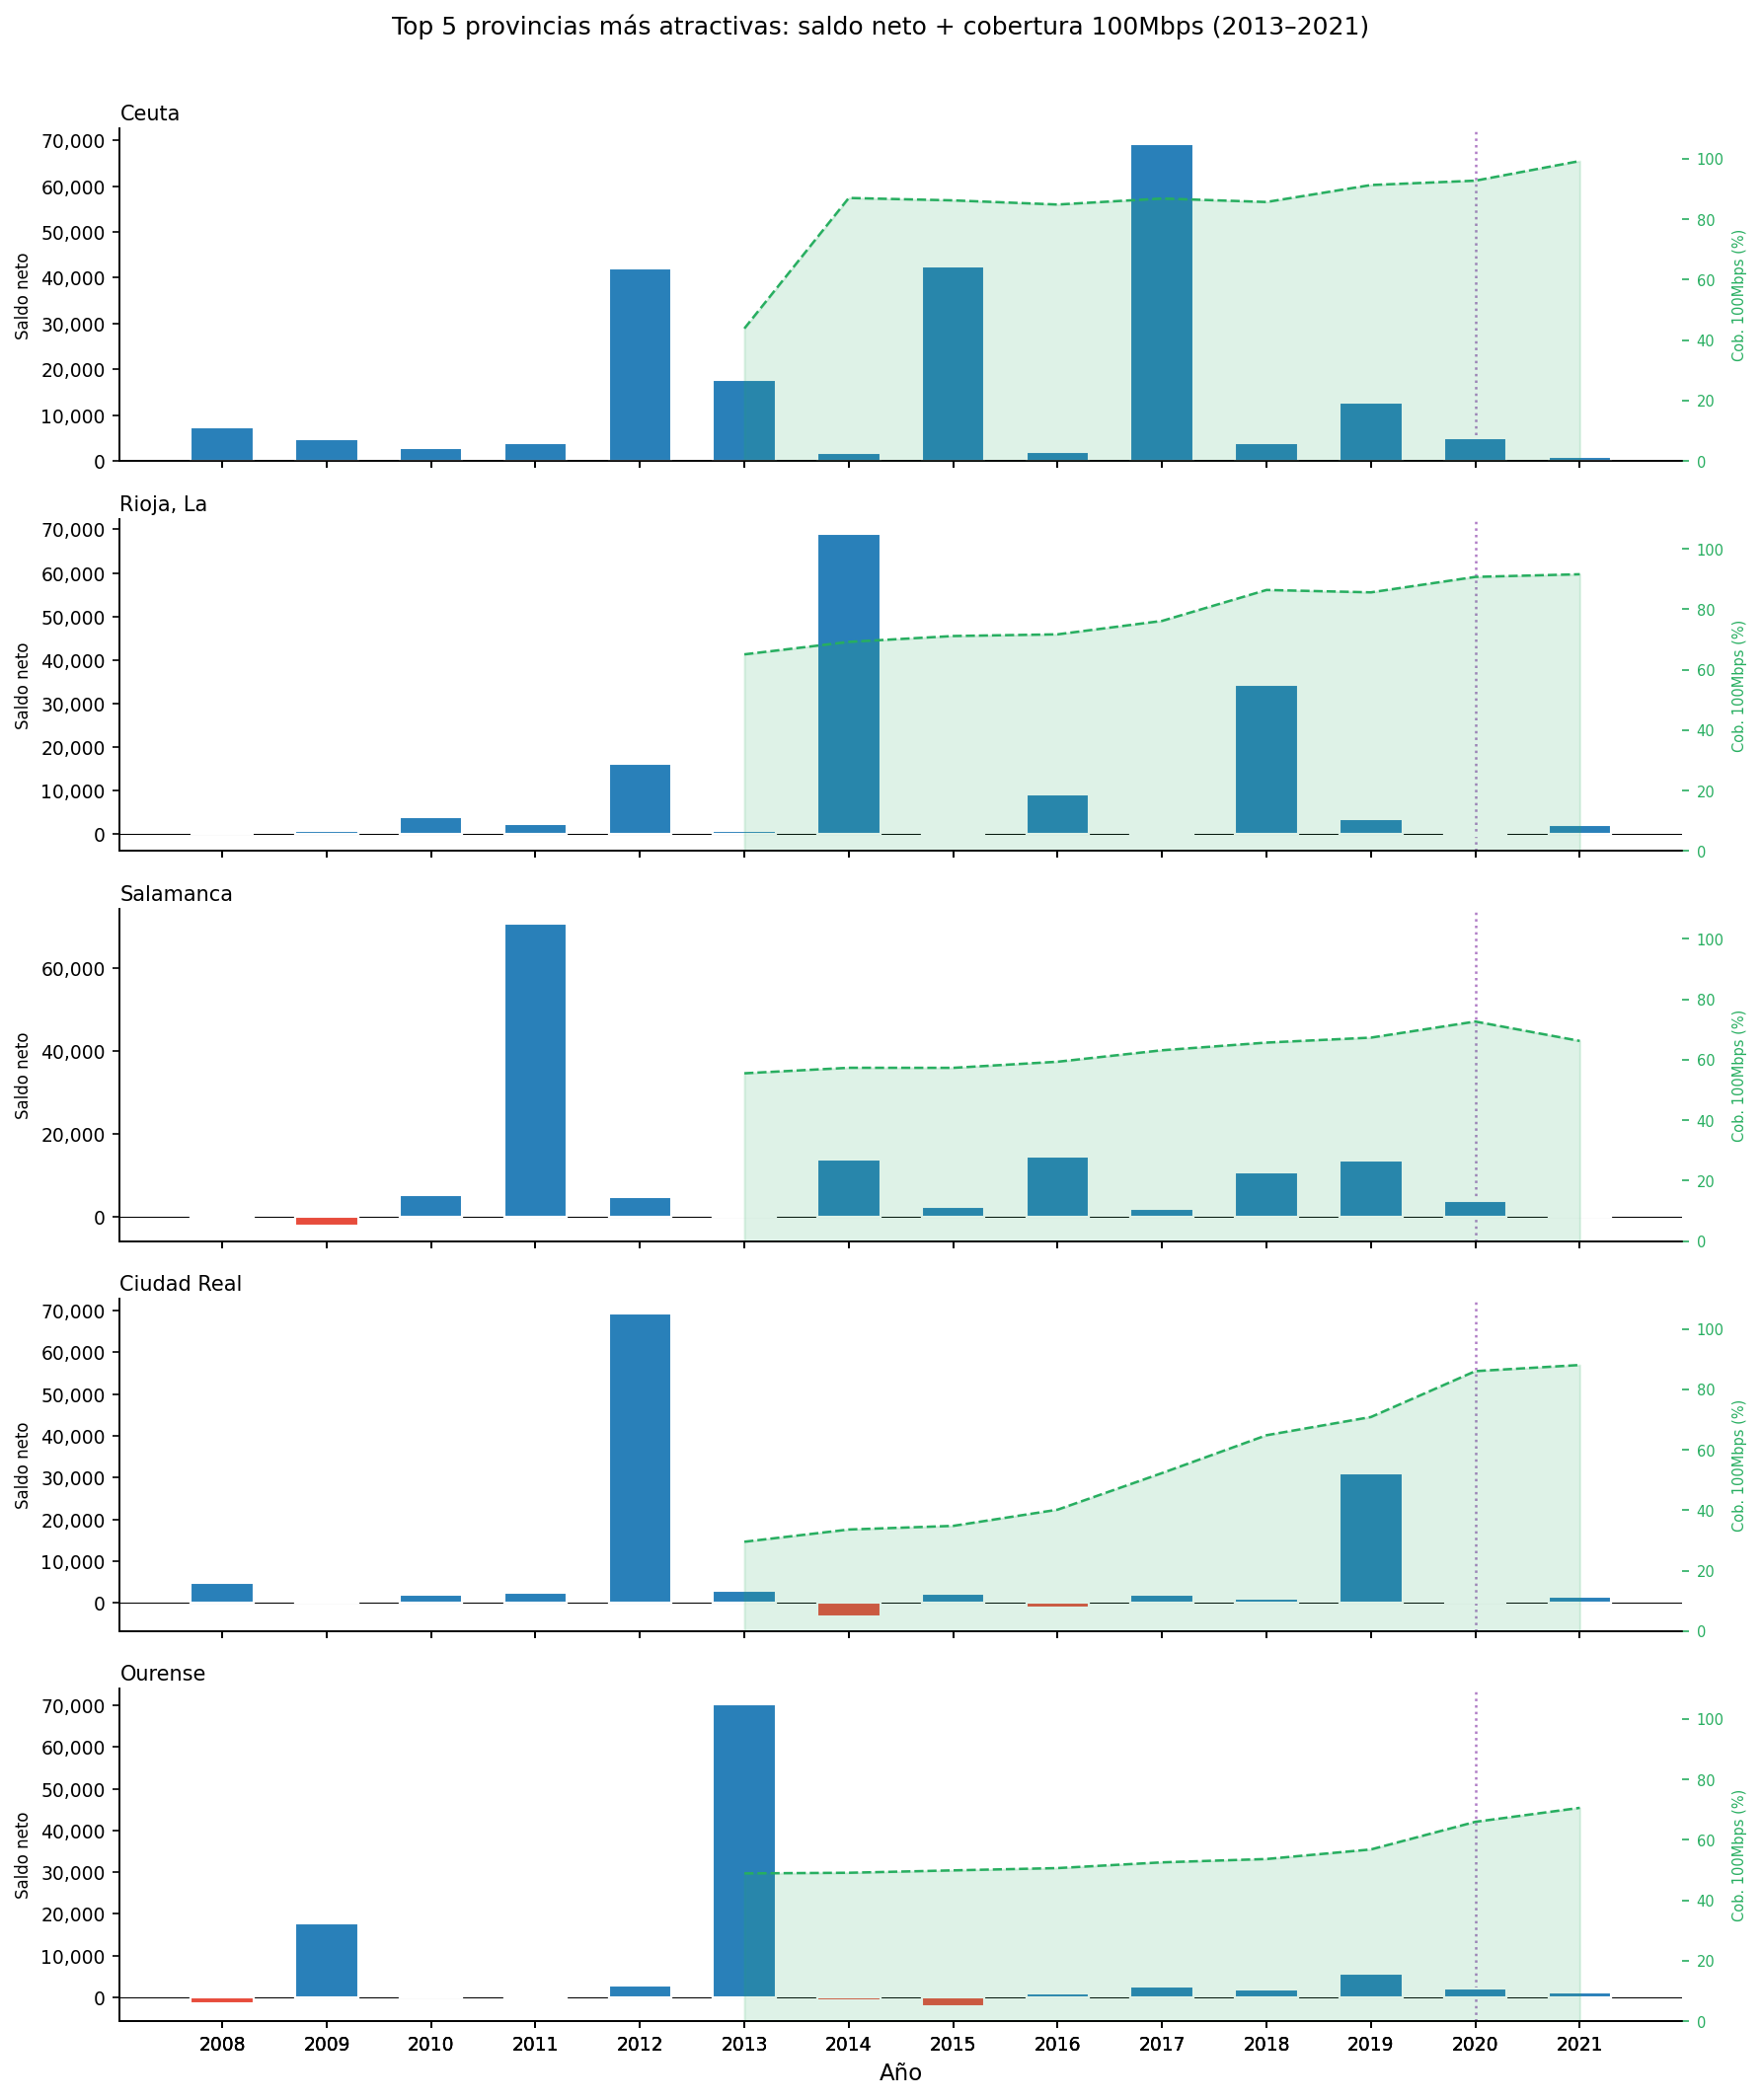

✅ 08_serie_top5_dual_axis.png


In [9]:
#============================================================
# Celda 9 — Serie temporal saldo + cobertura dual axis (top 5)
#============================================================
top5 = (master.groupby("provincia")["saldo_neto"]
        .mean().nlargest(5).index.tolist())

sub_top5 = master[master["provincia"].isin(top5)].sort_values(["provincia", "anyo"])

fig, axes = plt.subplots(len(top5), 1, figsize=(12, 14), sharex=True)
palette = plt.cm.tab10.colors

for i, (prov, ax) in enumerate(zip(top5, axes)):
    df_p = sub_top5[sub_top5["provincia"] == prov]

    ax2 = ax.twinx()
    ax2.fill_between(df_p["anyo"], df_p["cob_100mbps_pct"],
                     alpha=0.15, color=C_COB)
    ax2.plot(df_p["anyo"], df_p["cob_100mbps_pct"],
             color=C_COB, linewidth=1.2, linestyle="--")
    ax2.set_ylim(0, 110)
    ax2.set_ylabel("Cob. 100Mbps (%)", fontsize=7, color=C_COB)
    ax2.tick_params(axis="y", labelsize=7, colors=C_COB)

    ax.bar(df_p["anyo"], df_p["saldo_neto"],
           color=[C_POS if v >= 0 else C_NEG for v in df_p["saldo_neto"]],
           edgecolor="white", width=0.6, zorder=3)
    ax.axhline(0, color="black", linewidth=0.5)
    ax.axvline(2020, color="#8e44ad", linewidth=1.2, linestyle=":", alpha=0.7)
    ax.set_ylabel("Saldo neto", fontsize=8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.set_title(prov, fontsize=10, loc="left", pad=4)
    ax.set_xticks(df_p["anyo"])

plt.suptitle("Top 5 provincias más atractivas: saldo neto + cobertura 100Mbps (2013–2021)",
             fontsize=12, y=1.01)
axes[-1].set_xlabel("Año")
plt.tight_layout()
plt.savefig(FIGS / "08_serie_top5_dual_axis.png", bbox_inches="tight")
plt.show()
print("✅ 08_serie_top5_dual_axis.png")

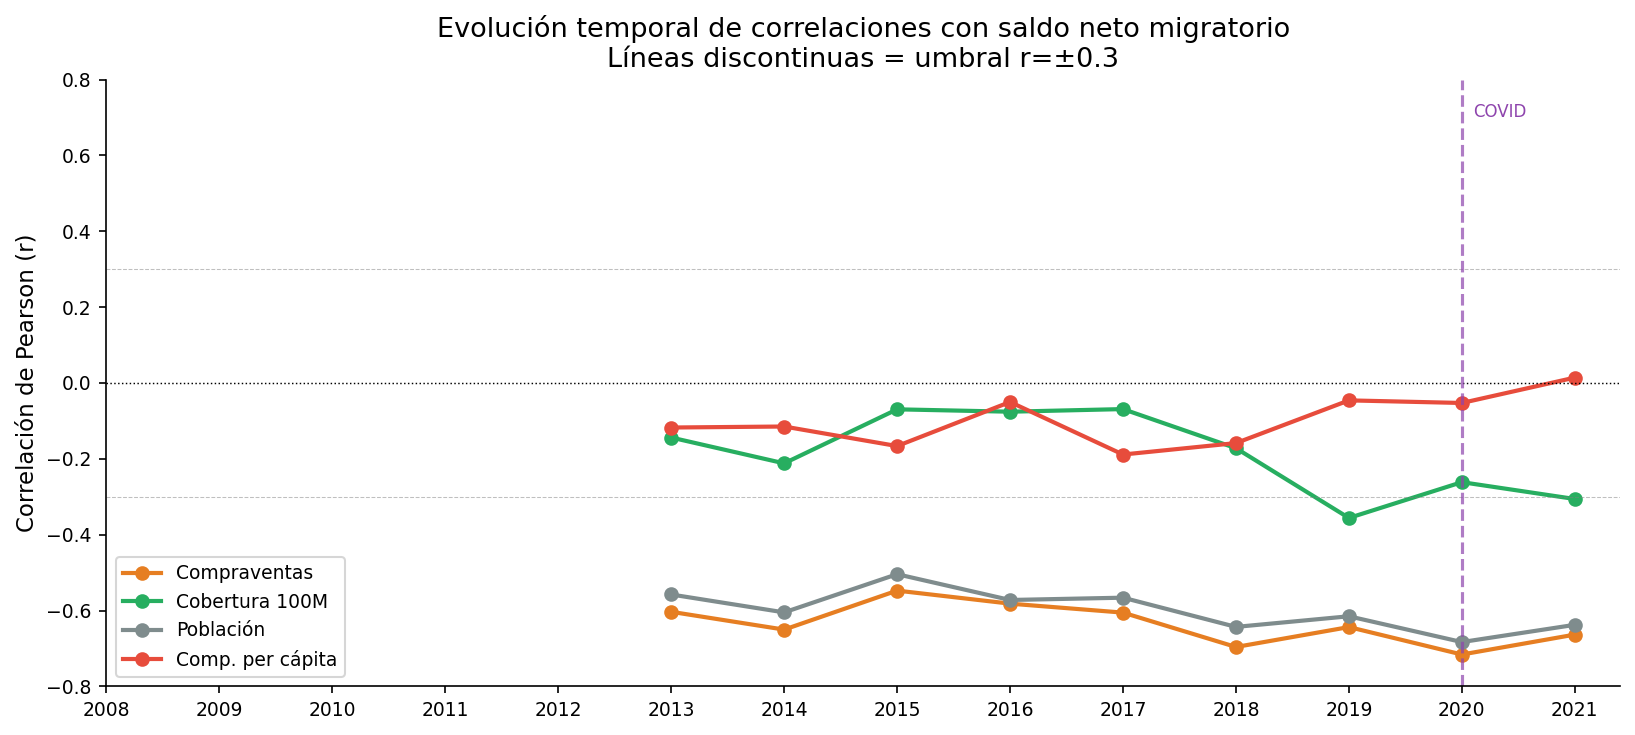

✅ 09_correlacion_temporal_evolucion.png


In [10]:
#============================================================
# Celda 10 — Evolución correlación de Pearson año a año (v2)
#============================================================
vars_corr = {
    "Compraventas":    "compraventas_vivienda",
    "Cobertura 100M":  "cob_100mbps_pct",
    "Población":       "poblacion_provincia",
    "Comp. per cápita":"compraventas_per_capita",
}

años = sorted(master["anyo"].unique())
corr_df = {k: [] for k in vars_corr}

for y in años:
    df_y = master[master["anyo"] == y].dropna(
        subset=["saldo_neto"] + list(vars_corr.values())
    )
    for nombre, col in vars_corr.items():
        # ← CORRECCIÓN: mínimo 3 obs y sin varianza cero
        x_vals = df_y[col].values
        y_vals = df_y["saldo_neto"].values
        if len(x_vals) >= 3 and x_vals.std() > 0 and y_vals.std() > 0:
            r, _ = stats.pearsonr(x_vals, y_vals)
        else:
            r = np.nan
        corr_df[nombre].append(r)

fig, ax = plt.subplots(figsize=(11, 5))
paleta = [C_COMP, C_COB, C_NEUT, C_NEG]

for (nombre, valores_r), color in zip(corr_df.items(), paleta):
    # Filtrar NaN para el plot
    años_plot = [a for a, v in zip(años, valores_r) if not np.isnan(v)]
    vals_plot  = [v for v in valores_r if not np.isnan(v)]
    ax.plot(años_plot, vals_plot, marker="o", linewidth=2,
            label=nombre, color=color)

ax.axhline(0,    color="black", linewidth=0.7, linestyle=":")
ax.axhline(0.3,  color="gray",  linewidth=0.5, linestyle="--", alpha=0.5)
ax.axhline(-0.3, color="gray",  linewidth=0.5, linestyle="--", alpha=0.5)
ax.axvline(2020, color="#8e44ad", linewidth=1.5, linestyle="--", alpha=0.7)
ax.text(2020.1, 0.7, "COVID", color="#8e44ad", fontsize=8)

ax.set_xticks(años)
ax.set_ylim(-0.8, 0.8)
ax.set_ylabel("Correlación de Pearson (r)")
ax.set_title("Evolución temporal de correlaciones con saldo neto migratorio\n"
             "Líneas discontinuas = umbral r=±0.3")
ax.legend(fontsize=9, loc="lower left")

plt.tight_layout()
plt.savefig(FIGS / "09_correlacion_temporal_evolucion.png")
plt.show()
print("✅ 09_correlacion_temporal_evolucion.png")

In [11]:
#============================================================
# Celda 11 — Cierre
#============================================================
print("=" * 55)
print("🏁 08_visualizaciones_finales completado")
print("=" * 55)
print(f"\n📁 Figuras → {FIGS}")
print("\n📈 Figuras generadas:")
for f in sorted(FIGS.glob("*.png")):
    print(f"   ✅ {f.name}")

🏁 08_visualizaciones_finales completado

📁 Figuras → output/08_visualizaciones_finales/figs

📈 Figuras generadas:
   ✅ 01_heatmap_provincia_anio.png
   ✅ 02_evolucion_saldo_nacional.png
   ✅ 03_ranking_ganadoras_perdedoras.png
   ✅ 04_scatter_cobertura_saldo_anotado.png
   ✅ 05_paradoja_compraventas_saldo.png
   ✅ 06_coeficientes_ols_ic95.png
   ✅ 07_r2_comparativa_modelos.png
   ✅ 08_serie_top5_dual_axis.png
   ✅ 09_correlacion_temporal_evolucion.png
